# 01. PyTorch Workflow Exercise Template

The following is a template for the PyTorch workflow exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [119]:
import torch
from torch import nn

In [120]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Create a straight line dataset using the linear regression formula (`weight * X + bias`).
  * Set `weight=0.3` and `bias=0.9` there should be at least 100 datapoints total.
  * Split the data into 80% training, 20% testing.
  * Plot the training and testing data so it becomes visual.

Your output of the below cell should look something like:
```
Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900])
y: tensor([0.9000, 0.9030, 0.9060, 0.9090, 0.9120, 0.9150, 0.9180, 0.9210, 0.9240,
        0.9270])
```

Of course the numbers in `X` and `y` may be different but ideally they're created using the linear regression formula.

In [121]:
weight = 0.3
bias = 0.9

torch.manual_seed(77)
X = torch.arange(start=0, end=4, step=0.04).unsqueeze(dim=1)
y = weight * X + bias

print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")
print(f"First 10 X & y samples:\nX: {X[:10]}\ny: {y[:10]}")

Number of X samples: 100
Number of y samples: 100
First 10 X & y samples:
X: tensor([[0.0000],
        [0.0400],
        [0.0800],
        [0.1200],
        [0.1600],
        [0.2000],
        [0.2400],
        [0.2800],
        [0.3200],
        [0.3600]])
y: tensor([[0.9000],
        [0.9120],
        [0.9240],
        [0.9360],
        [0.9480],
        [0.9600],
        [0.9720],
        [0.9840],
        [0.9960],
        [1.0080]])


In [122]:
train_split = int(0.8 * len(X))

X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([80, 1]),
 torch.Size([20, 1]),
 torch.Size([80, 1]),
 torch.Size([20, 1]))

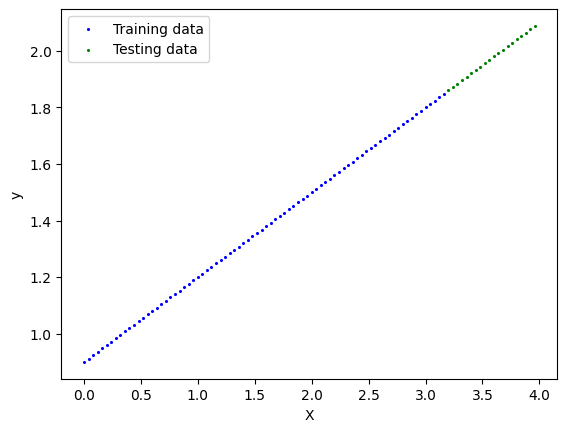

In [123]:
import matplotlib.pyplot as plt

def plot_predictions(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, predictions=None):
  X_train = X_train.to("cpu")
  X_test = X_test.to("cpu")
  y_train = y_train.to("cpu")
  y_test = y_test.to("cpu")

  plt.scatter(X_train, y_train, s=1.5, c="b", label="Training data")
  plt.scatter(X_test, y_test, s=1.5, c="g", label="Testing data")

  if predictions is not None:
    predictions = predictions.to("cpu")
    plt.scatter(X_test, predictions, s=1.5, c="r", label="Predictions")
    predictions = predictions.to("cuda")

  plt.xlabel("X")
  plt.ylabel("y")

  plt.legend()

  X_train = X_train.to("cuda")
  X_test = X_test.to("cuda")
  y_train = y_train.to("cuda")
  y_test = y_test.to("cuda")

plot_predictions()


## 2. Build a PyTorch model by subclassing `nn.Module`.
  * Inside should be a randomly initialized `nn.Parameter()` with `requires_grad=True`, one for `weights` and one for `bias`.
  * Implement the `forward()` method to compute the linear regression function you used to create the dataset in 1.
  * Once you've constructed the model, make an instance of it and check its `state_dict()`.
  * **Note:** If you'd like to use `nn.Linear()` instead of `nn.Parameter()` you can.

In [124]:
from typing import Optional, Tuple
from torch.utils.data import TensorDataset, DataLoader

class LinearRegressionModel(nn.Module):
  def __init__(self, device: Optional[torch.device] = None, dtype: torch.dtype = torch.float32):
    super().__init__()

    self.device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    self.dtype = dtype

    self.linear = nn.Linear(in_features=1, out_features=1)

    self.to(device=self.device)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear(x)

In [125]:
torch.manual_seed(77)

model = LinearRegressionModel()
model.state_dict()

OrderedDict([('linear.weight', tensor([[-0.4162]], device='cuda:0')),
             ('linear.bias', tensor([-0.4286], device='cuda:0'))])

## 3. Create a loss function and optimizer using `nn.L1Loss()` and `torch.optim.SGD(params, lr)` respectively.
  * Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
  * Write a training loop to perform the appropriate training steps for 300 epochs.
  * The training loop should test the model on the test dataset every 20 epochs.

In [126]:
# Create the loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


In [127]:
def train_loop(epochs: int):
  for epoch in range(epochs):
    model.train()

    preds = model(X_train)

    loss = loss_fn(preds, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
      model.eval()
      with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

      print(f"Epoch: {epoch} | Train loss: {loss:.3f} | Test loss: {test_loss:.3f}")


X_train = X_train.to(device=model.device)
X_test = X_test.to(device=model.device)
y_train = y_train.to(device=model.device)
y_test = y_test.to(device=model.device)

# Train model for 300 epochs
print(model.device)
train_loop(10000)


cuda
Epoch: 0 | Train loss: 6.490 | Test loss: 14.891
Epoch: 100 | Train loss: 1.341 | Test loss: 1.832
Epoch: 200 | Train loss: 0.358 | Test loss: 0.078
Epoch: 300 | Train loss: 0.163 | Test loss: 0.035
Epoch: 400 | Train loss: 0.119 | Test loss: 0.137
Epoch: 500 | Train loss: 0.104 | Test loss: 0.192
Epoch: 600 | Train loss: 0.094 | Test loss: 0.209
Epoch: 700 | Train loss: 0.087 | Test loss: 0.207
Epoch: 800 | Train loss: 0.080 | Test loss: 0.197
Epoch: 900 | Train loss: 0.073 | Test loss: 0.184
Epoch: 1000 | Train loss: 0.068 | Test loss: 0.170
Epoch: 1100 | Train loss: 0.062 | Test loss: 0.157
Epoch: 1200 | Train loss: 0.057 | Test loss: 0.145
Epoch: 1300 | Train loss: 0.053 | Test loss: 0.134
Epoch: 1400 | Train loss: 0.049 | Test loss: 0.123
Epoch: 1500 | Train loss: 0.045 | Test loss: 0.113
Epoch: 1600 | Train loss: 0.041 | Test loss: 0.104
Epoch: 1700 | Train loss: 0.038 | Test loss: 0.096
Epoch: 1800 | Train loss: 0.035 | Test loss: 0.088
Epoch: 1900 | Train loss: 0.032 | Tes

## 4. Make predictions with the trained model on the test data.
  * Visualize these predictions against the original training and testing data (**note:** you may need to make sure the predictions are *not* on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

In [128]:
model.eval()
with torch.inference_mode():
  preds = model(X_test)

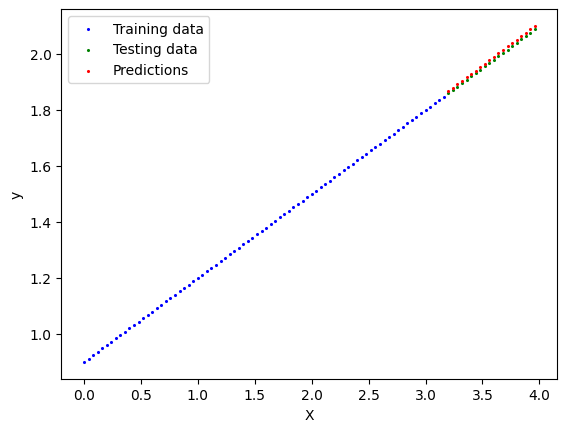

In [129]:
# Plot the predictions (these may need to be on a specific device)
plot_predictions(predictions=preds)

## 5. Save your trained model's `state_dict()` to file.
  * Create a new instance of your model class you made in 2. and load in the `state_dict()` you just saved to it.
  * Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [130]:
from pathlib import Path

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / 'model.pth'

torch.save(obj=model.state_dict(), f=MODEL_PATH)

In [133]:
loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(f=MODEL_PATH))


<All keys matched successfully>

In [134]:
loaded_preds = loaded_model(X_test)
print(loaded_preds == preds)


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')
